<a href="https://colab.research.google.com/github/rahilkhan-acadmic/APAIML-GradedMiniProject/blob/develop/Module_37_Graded_Mini_Project_Khan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib as plt
import numpy as np
from tensorflow.keras import layers

# Part 1: Data Preparation
## 1. Dataset Loading
### Split into training and testing subsets

In [5]:
(ds_train,_),ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:90%]','train[90%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
    )

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.1KSHP0_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


## 2. Preprocessing:
### o Resize all images to 64×64 pixels
### o Normalize pixel values to the [-1, 1] range
### o Cast labels to integer format
### o Create training batches with labels

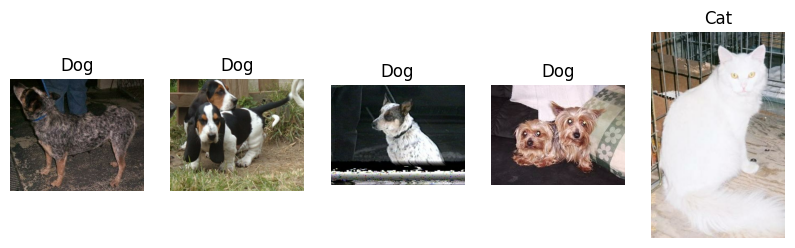

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i, (image, label) in enumerate(ds_train.take(5)): # Display 5 images
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title('Dog' if label == 1 else 'Cat')
    plt.axis('off')
plt.show()

In [14]:
# Define target dimension
TARGET_HEIGHT = 64
TARGET_WIDTH = 64

def preprocess_image(image, label):
    # Resize all images to 64x64 pixels
    image = tf.image.resize(image, (TARGET_HEIGHT, TARGET_WIDTH))
    # Normalize pixel values to the [-1, 1] range
    image = tf.keras.layers.Rescaling(scale=1./127.5, offset=-1)(image)
    # Cast labels to integer format (tfds.load with as_supervised usually does this, but good to be explicit)
    label = tf.cast(label, tf.int32)
    return image, label

In [18]:
BATCH_SIZE = 32

ds_train_processed = ds_train.map(preprocess_image)
ds_train_batched = ds_train_processed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

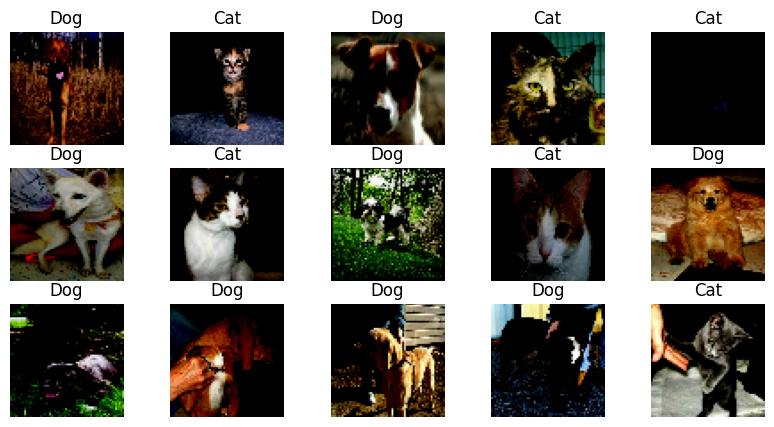

In [22]:
plt.figure(figsize=(10, 5))
for i, (image, label) in enumerate(ds_train_batched.take(15)): # Display 15 images
    plt.subplot(3, 5, i + 1)
    plt.imshow((image[0])) # Denormalize from [-1, 1] to [0, 1] for display
    # plt.imshow((image[0] + 1) / 2) # Denormalize from [-1, 1] to [0, 1] for display
    plt.title('Dog' if label[0] == 1 else 'Cat') # Use the label of the first image
    plt.axis('off')
plt.show()